Python program to implement a generative adversarial network using pytorch which generates handwritten digits using mnist dataset.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os


In [ ]:
# Hyperparameters
latent_dim = 100
batch_size = 128
lr = 0.0002
epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # scale to [-1, 1]
])

mnist = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
dataloader = DataLoader(mnist, batch_size=batch_size, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 146MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 42.7MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 24.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.11MB/s]


In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 28*28),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(z.size(0), 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)


In [ ]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

loss_fn = nn.BCELoss()
opt_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
opt_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))


In [ ]:
fixed_noise = torch.randn(25, latent_dim, device=device)

for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        batch_size_curr = real_imgs.size(0)

        # Labels
        real = torch.ones(batch_size_curr, 1, device=device)
        fake = torch.zeros(batch_size_curr, 1, device=device)

        # ---------------------
        #  Train Discriminator
        # ---------------------
        noise = torch.randn(batch_size_curr, latent_dim, device=device)
        gen_imgs = generator(noise)

        real_loss = loss_fn(discriminator(real_imgs), real)
        fake_loss = loss_fn(discriminator(gen_imgs.detach()), fake)
        d_loss = real_loss + fake_loss

        opt_D.zero_grad()
        d_loss.backward()
        opt_D.step()

        # -----------------
        #  Train Generator
        # -----------------
        gen_imgs = generator(noise)
        g_loss = loss_fn(discriminator(gen_imgs), real)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

    print(f"[Epoch {epoch+1}/{epochs}] D_loss: {d_loss.item():.4f} G_loss: {g_loss.item():.4f}")


[Epoch 1/50] D_loss: 0.7831 G_loss: 1.4481
[Epoch 2/50] D_loss: 0.7480 G_loss: 1.4345
[Epoch 3/50] D_loss: 1.1705 G_loss: 3.1825
[Epoch 4/50] D_loss: 0.9952 G_loss: 1.2174
[Epoch 5/50] D_loss: 1.0061 G_loss: 3.7464
[Epoch 6/50] D_loss: 0.7734 G_loss: 1.6316
[Epoch 7/50] D_loss: 0.7505 G_loss: 2.1394
[Epoch 8/50] D_loss: 0.8784 G_loss: 1.2357
[Epoch 9/50] D_loss: 1.0971 G_loss: 3.2189
[Epoch 10/50] D_loss: 1.0859 G_loss: 2.7264
[Epoch 11/50] D_loss: 0.8429 G_loss: 1.8645
[Epoch 12/50] D_loss: 0.8988 G_loss: 1.3560
[Epoch 13/50] D_loss: 0.9399 G_loss: 1.2400
[Epoch 14/50] D_loss: 1.1500 G_loss: 1.8164
[Epoch 15/50] D_loss: 1.3379 G_loss: 1.9816
[Epoch 16/50] D_loss: 0.9991 G_loss: 1.1349
[Epoch 17/50] D_loss: 1.1765 G_loss: 0.8116
[Epoch 18/50] D_loss: 1.1136 G_loss: 1.1651
[Epoch 19/50] D_loss: 1.1993 G_loss: 1.7123
[Epoch 20/50] D_loss: 1.2091 G_loss: 1.5315
[Epoch 21/50] D_loss: 1.1615 G_loss: 0.8647
[Epoch 22/50] D_loss: 1.1746 G_loss: 0.7308
[Epoch 23/50] D_loss: 1.2653 G_loss: 0.64

In [ ]:
def show_generated(generator, fixed_noise):
    generator.eval()
    with torch.no_grad():
        gen_imgs = generator(fixed_noise).cpu()
    gen_imgs = gen_imgs * 0.5 + 0.5  # Denormalize

    grid = np.transpose(torchvision.utils.make_grid(gen_imgs, nrow=5, padding=2, normalize=False), (1, 2, 0))
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.squeeze(), cmap='gray')
    plt.axis('off')
    plt.title("Generated Digits")
    plt.show()


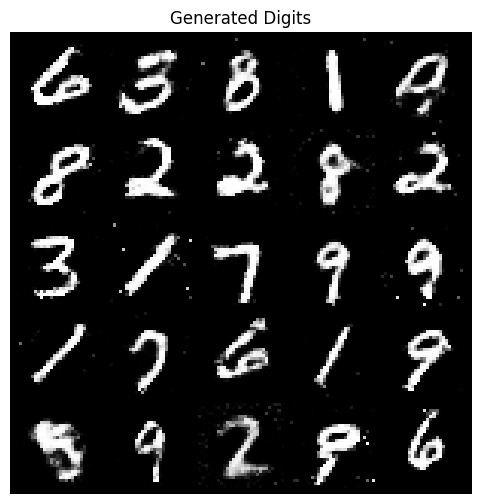

In [ ]:
show_generated(generator, fixed_noise)


Optimizers


In [ ]:
from tensorflow.keras.datasets import mnist
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
(x,y),(xval,yval) = mnist.load_data()

In [ ]:
print("Shape of training image {} and training label {}".format(x.shape,y.shape))

Shape of training image (60000, 28, 28) and training label (60000,)


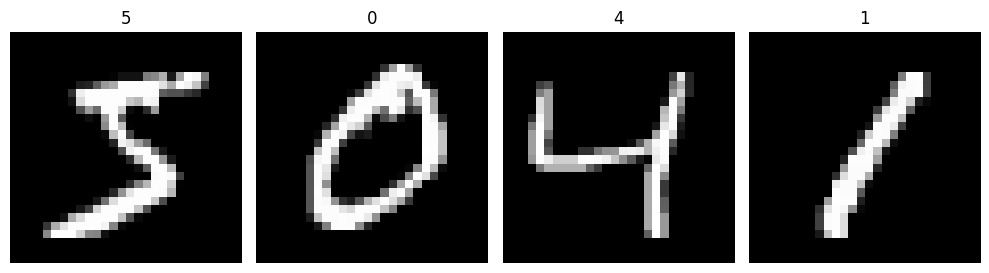

In [ ]:
plt.figure(figsize=(10,5))
for i in range(4):
  plt.subplot(1,4,i+1)
  plt.imshow(x[i],cmap='gray')
  plt.title(y[i])
  plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
epoch = 10
hidden_size = 150

In [ ]:
#Do one hot encoding

In [ ]:
LOSS_FUNCTION = "sparse_categorical_crossentropy"
METRICS = ["accuracy"]


In [ ]:
histories = {}
optimizers = ['SGD', 'Adam', 'RMSprop', 'Adagrad']

In [ ]:
for opt in optimizers:
    model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=[28, 28]),
  tf.keras.layers.Dense(hidden_size, activation="relu"),
  tf.keras.layers.Dense(10, activation="softmax")
])

    model.compile(loss=LOSS_FUNCTION, optimizer=opt, metrics=METRICS)

    history = model.fit(x, y, epochs=epoch, verbose=0, validation_data=(xval,yval))

    histories[opt] = history.history['val_accuracy']

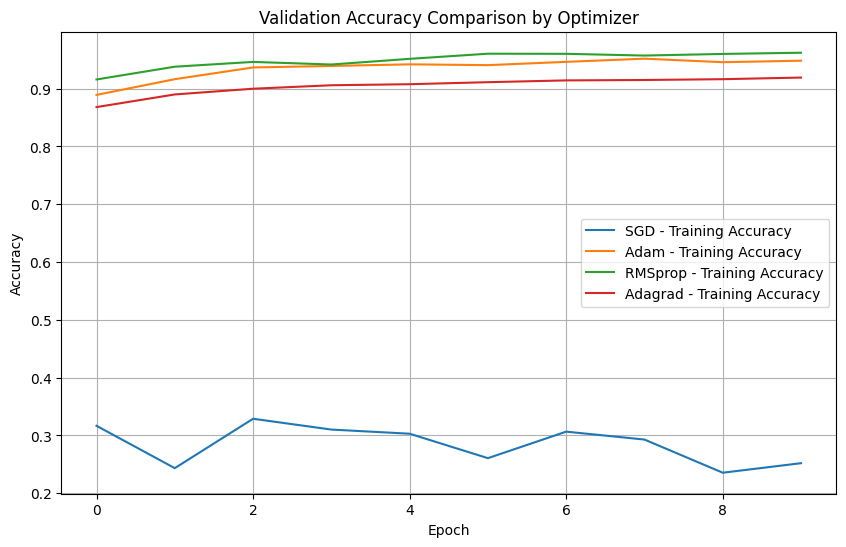

In [ ]:
plt.figure(figsize=(10, 6))
for opt in optimizers:
    plt.plot(histories[opt], label=f'{opt} - Training Accuracy')

plt.title('Validation Accuracy Comparison by Optimizer')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

PCA MDS on Winedata

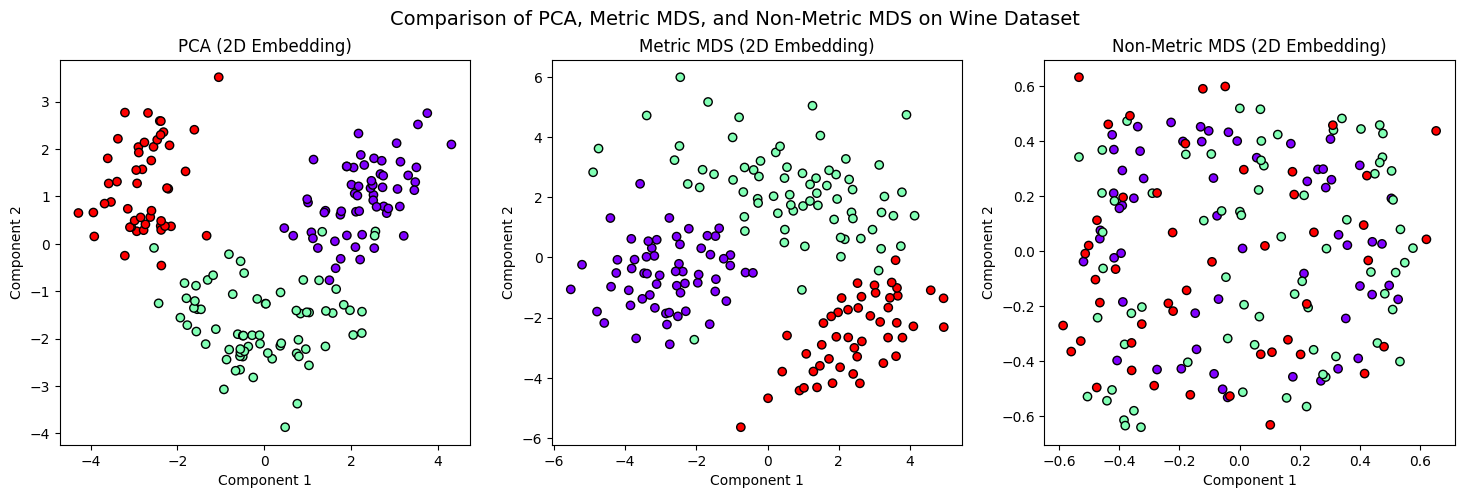

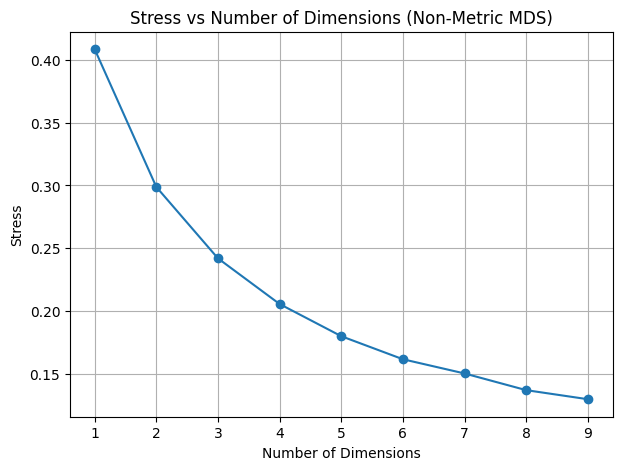

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.preprocessing import StandardScaler
import pandas as pd
# Load and Standardize the Wine dataset
data = load_wine()
X = data.data
y = data.target
X_scaled = StandardScaler().fit_transform(X)
# Apply PCA (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
# Apply Metric MDS (2D)
mds_metric = MDS(n_components=2, metric=True, random_state=42, n_init=4, max_iter=300)
X_mds_metric = mds_metric.fit_transform(X_scaled)
# Apply Non-Metric MDS (2D)
mds_nonmetric = MDS(n_components=2, metric=False, random_state=42, n_init=4, max_iter=300)
X_mds_nonmetric = mds_nonmetric.fit_transform(X_scaled)
# Visualize embeddings side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
methods = ["PCA", "Metric MDS", "Non-Metric MDS"]
embeddings = [X_pca, X_mds_metric, X_mds_nonmetric]

for ax, method, X_emb in zip(axes, methods, embeddings):
    scatter = ax.scatter(X_emb[:, 0], X_emb[:, 1], c=y, cmap='rainbow', edgecolor='k')
    ax.set_title(f"{method} (2D Embedding)")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")

plt.suptitle("Comparison of PCA, Metric MDS, and Non-Metric MDS on Wine Dataset", fontsize=14)
plt.show()
stress_values = []
dimensions = range(1, 10)

for dim in dimensions:
    mds = MDS(n_components=dim, metric=False, random_state=42, n_init=2, max_iter=200)
    mds.fit(X_scaled)
    stress_values.append(mds.stress_)
# Plot Stress vs Dimensions
plt.figure(figsize=(7,5))
plt.plot(dimensions, stress_values, marker='o')
plt.title("Stress vs Number of Dimensions (Non-Metric MDS)")
plt.xlabel("Number of Dimensions")
plt.ylabel("Stress")
plt.grid(True)
plt.show()

PPCA Image Compression

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
PCA MSE: 0.0118
PPCA MSE: 0.0141


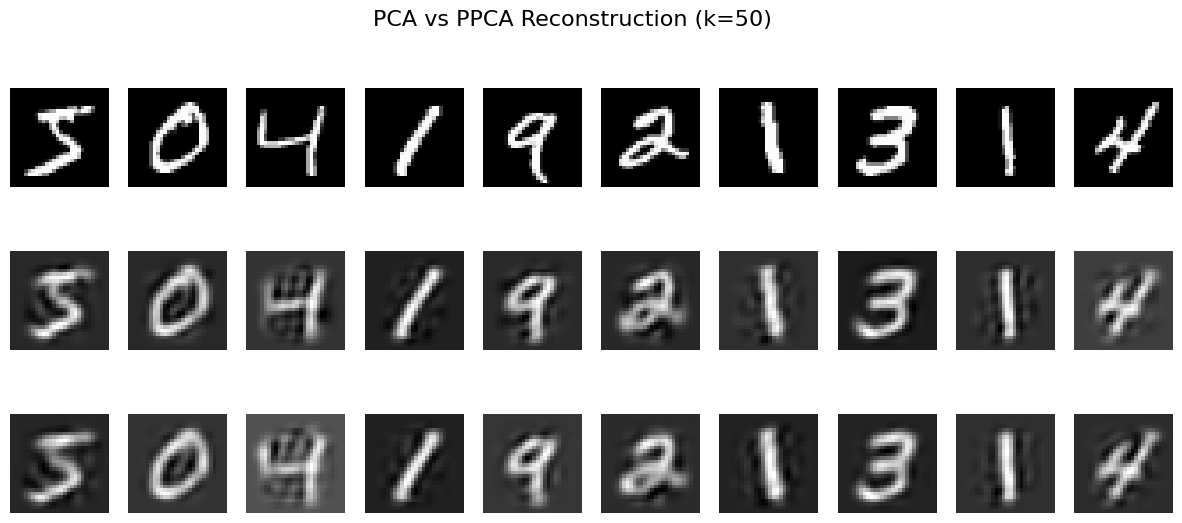

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.metrics import mean_squared_error
from tensorflow.keras.datasets import mnist



# Load dataset
(X_train, _), _ = mnist.load_data()
X = X_train.reshape(-1, 28*28) / 255.0  # normalize

# Parameters
k = 50  # number of components



# PCA
pca = PCA(n_components=k)
X_pca = pca.fit_transform(X)   # <-- use fit_transform instead of just transform
X_pca_recon = pca.inverse_transform(X_pca)
mse_pca = mean_squared_error(X, X_pca_recon)



# PPCA (via FactorAnalysis)
ppca = FactorAnalysis(n_components=k)
X_ppca = ppca.fit_transform(X)
X_ppca_recon = X_ppca @ ppca.components_ + ppca.mean_
mse_ppca = mean_squared_error(X, X_ppca_recon)


print(f"PCA MSE: {mse_pca:.4f}")
print(f"PPCA MSE: {mse_ppca:.4f}")

n = 10  # number of images to display
plt.figure(figsize=(15, 6))

# Titles for each row
row_titles = ["Original", "PCA Reconstruction", "PPCA Reconstruction"]

for row in range(3):
    for i in range(n):
        plt.subplot(3, n, row*n + i + 1)

        if row == 0:
            plt.imshow(X[i].reshape(28, 28), cmap="gray")
        elif row == 1:
            plt.imshow(X_pca_recon[i].reshape(28, 28), cmap="gray")
        else:
            plt.imshow(X_ppca_recon[i].reshape(28, 28), cmap="gray")

        plt.axis("off")

        # Add row labels on the first column
        if i == 0:
            plt.ylabel(row_titles[row], fontsize=12)

plt.suptitle(f"PCA vs PPCA Reconstruction (k={k})", fontsize=16)
plt.show()

